# 02 - Autoencoder (não supervisionado)

Modelo 1 do projeto. Treina um **autoencoder convolucional** (PyTorch) apenas com imagens normais. Em teste, o **erro de reconstrução** funciona como score de anomalia: erro alto = provável defeito. Avaliação por **AUROC** (~0.89).

In [1]:
import sys
sys.path.append("../src")

import torch
import matplotlib.pyplot as plt
from dataset import criar_dataloaders
from autoencoder import Autoencoder
from treino import treinar_melhor

device = "cuda" if torch.cuda.is_available() else "cpu"
print("A usar:", device)

A usar: cuda


In [2]:
train_loader, test_loader = criar_dataloaders(
    root="../data/mvtec",
    category="bottle",
    batch_size=16
)

Categoria: bottle
  Treino: 209 imagens normais
  Teste:  83 imagens (63 defeituosas)


In [3]:
modelo = Autoencoder()
print("Parâmetros do modelo:", sum(p.numel() for p in modelo.parameters()))

# Treina e guarda automaticamente o melhor modelo em ../models/autoencoder_bottle_best.pth
historico = treinar_melhor(
    modelo=modelo,
    train_loader=train_loader,
    num_epochs=50,
    lr=1e-3,
    device=device
)

Parâmetros do modelo: 5578051


Epoch 1/50:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch 1/50:   7%|▋         | 1/14 [00:01<00:13,  1.05s/it]

Epoch 1/50:  14%|█▍        | 2/14 [00:01<00:08,  1.39it/s]

Epoch 1/50:  21%|██▏       | 3/14 [00:02<00:06,  1.62it/s]

...

Epoch 50/50:  71%|███████▏  | 10/14 [00:06<00:02,  1.53it/s]

Epoch 50/50:  79%|███████▊  | 11/14 [00:07<00:01,  1.53it/s]

Epoch 50/50:  86%|████████▌ | 12/14 [00:07<00:01,  1.53it/s]

Epoch 50/50:  93%|█████████▎| 13/14 [00:08<00:00,  1.42it/s]

Epoch 50/50 — Loss: 0.0130 | Melhor: 0.0120

Treino concluído! Melhor loss: 0.0120


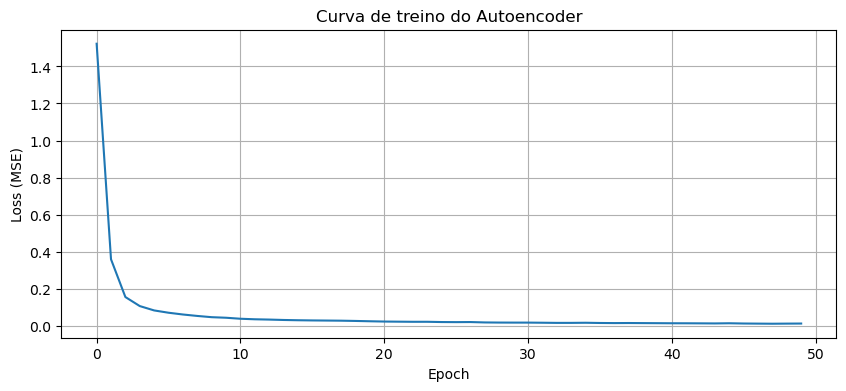

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(historico)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Curva de treino do Autoencoder")
plt.grid(True)
plt.show()

In [5]:
import os
os.makedirs("../models", exist_ok=True)
torch.save(modelo.state_dict(), "../models/autoencoder_bottle.pth")
print("Modelo guardado!")

Modelo guardado!


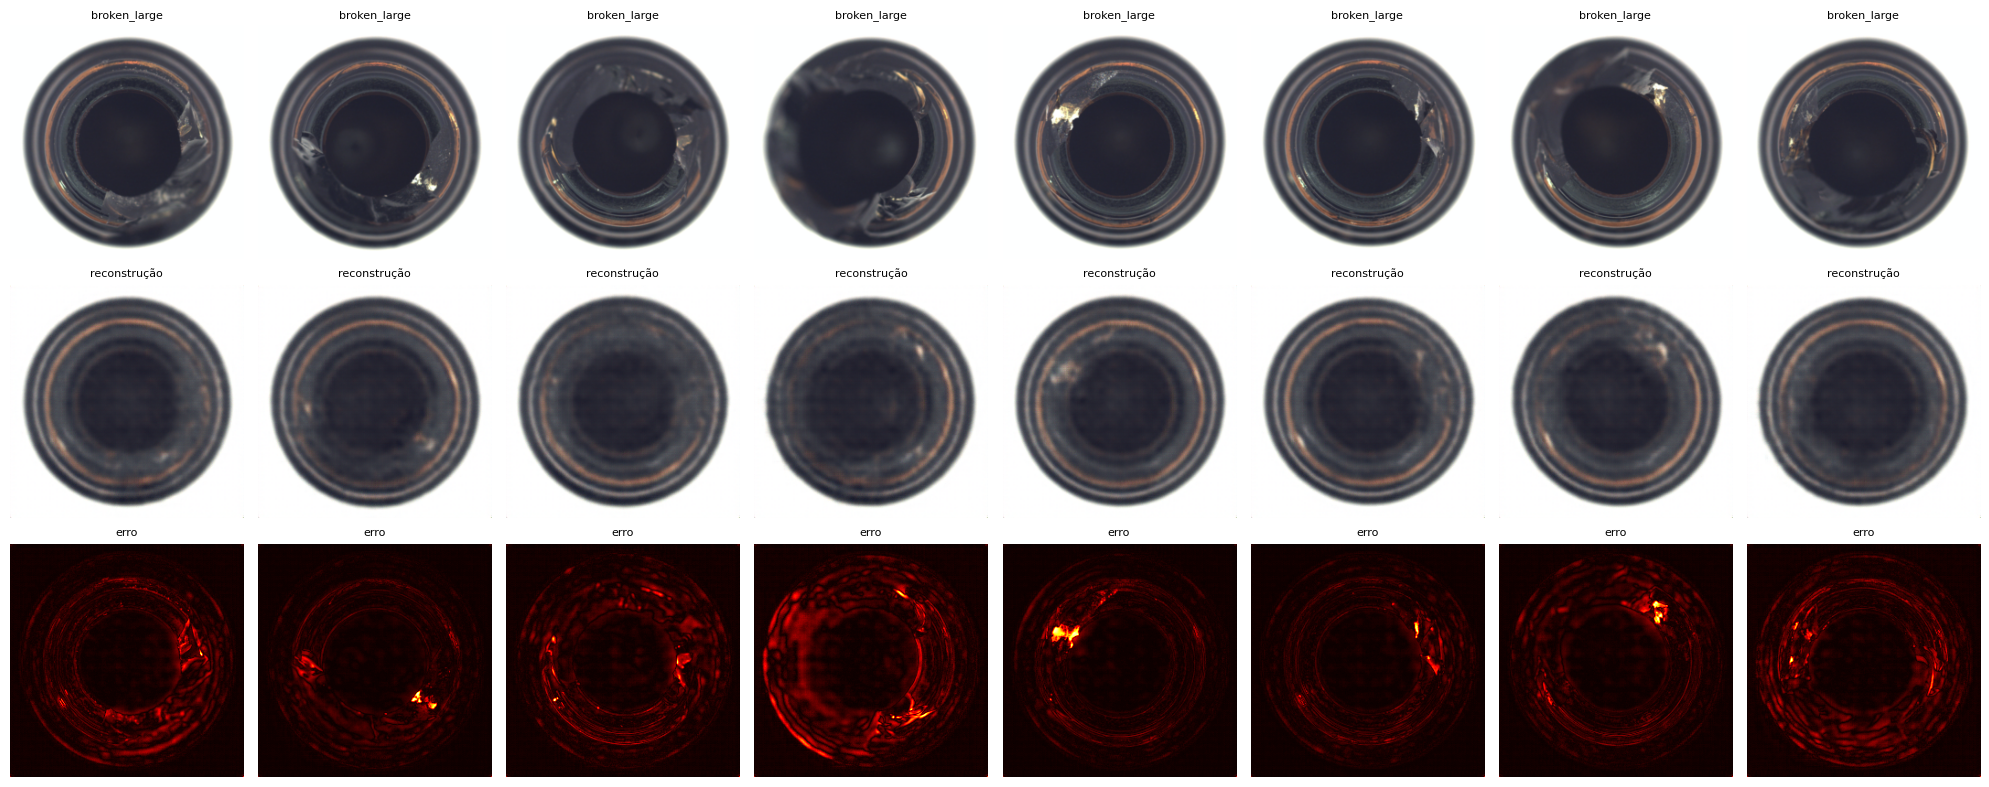

In [6]:
import numpy as np

def desnormalizar(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()
    img = img * std + mean
    return np.clip(img, 0, 1)

modelo.eval()
imgs, labels, tipos = next(iter(test_loader))
imgs = imgs.to(device)

with torch.no_grad():
    reconstrucoes = modelo(imgs.to(device))

# Mostra original vs reconstrução
fig, axes = plt.subplots(3, 8, figsize=(20, 8))

for i in range(8):
    # Linha 1: imagem original
    axes[0, i].imshow(desnormalizar(imgs[i].cpu()))
    axes[0, i].set_title(tipos[i], fontsize=8)
    axes[0, i].axis("off")
    
    # Linha 2: reconstrução do modelo
    axes[1, i].imshow(desnormalizar(reconstrucoes[i].cpu()))
    axes[1, i].set_title("reconstrução", fontsize=8)
    axes[1, i].axis("off")
    
    # Linha 3: mapa de erro (diferença)
    erro = torch.abs(imgs[i].cpu() - reconstrucoes[i].cpu())
    erro = erro.mean(dim=0).numpy()  # média dos 3 canais
    axes[2, i].imshow(erro, cmap="hot")
    axes[2, i].set_title("erro", fontsize=8)
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Reconstrução", fontsize=10)
axes[2, 0].set_ylabel("Mapa de erro", fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
from sklearn.metrics import roc_auc_score
import torch

modelo.eval()
criterio = torch.nn.MSELoss(reduction='none')

scores = []   # anomaly score de cada imagem
labels_all = []

with torch.no_grad():
    for imgs, labels, _ in test_loader:
        imgs = imgs.to(device)
        reconstrucoes = modelo(imgs)
        
        # Erro médio por imagem (score de anomalia)
        erro = criterio(reconstrucoes, imgs)
        erro_por_imagem = erro.mean(dim=[1,2,3])  # média sobre C,H,W
        
        scores.extend(erro_por_imagem.cpu().numpy())
        labels_all.extend(labels.numpy())

auroc = roc_auc_score(labels_all, scores)
print(f"AUROC: {auroc:.4f}")
print("(0.5 = aleatório, 1.0 = perfeito)")

AUROC: 0.9310
(0.5 = aleatório, 1.0 = perfeito)
